# Events analysis

In [21]:
%matplotlib inline

# Data integration libraries
from pathlib import Path
import sys

# Data analysis libraries
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data visualization and control libraries
from IPython.display import display
import time

# Locate code from all the implementation root
implementation_root = Path("..").resolve()
sys.path.append(str(implementation_root))

# TUH Corpus structure
from models.data_preparation_preprocessing.data_config import BASE_PATH, CORPUS_PATHS
print("Path of all the Corpus:\n", BASE_PATH, "\n", CORPUS_PATHS)

# EDF visualization
mne.viz.set_browser_backend("matplotlib")

Path of all the Corpus:
 \\Cit114pc07\data_eeg_tuh\ 
 {'all_corpus': WindowsPath('tuh_eeg/v2.0.2'), 'artifact': WindowsPath('tuh_eeg_artifact/v3.0.1'), 'epilepsy': WindowsPath('tuh_eeg_epilepsy/v3.1.0'), 'seizure': WindowsPath('tuh_eeg_seizure/v2.0.6'), 'events': WindowsPath('tuh_eeg_events/v2.0.1')}


'matplotlib'

## TUH EEG Artifact Corpus EDA


This subset contains annotations of 5 different artifacts:
- Eye movement
- Chewing
- Shivering
- Electrode pop, electrode static and lead artifactos
- Muscle artifacts

In [2]:
# Pandas table display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 20)
pd.set_option("display.width", 1000)

### EDF files

In [3]:
# Corpus signal data
def get_edf_data(base_path, corpus_name, n_seconds=10):
    """
    Returns all signal parameters of a specific corpus.
    """
    corpus_path = base_path / CORPUS_PATHS[corpus_name]
    montages = [
        "01_tcp_ar", "02_tcp_le", "03_tcp_ar_a", "04_tcp_le_a",
        "05_tcp_ar_b", "06_tcp_le_b", "07_tcp_ar_c", "08_tcp_le_c"
    ]

    registers = []

    for session in corpus_path.rglob("*.edf"):
        montage = session.parent.name if session.parent.name in montages else None
        document_name = Path(session.name).stem
        session_id = next((part for part in document_name.split("_") if part.startswith("s") and part[1:].isdigit()), None)
        pacient = next((part for part in document_name.split("_") if len(part) == 8 and part.isalpha()), None)
        session_section = next((part for part in document_name.split("_") if part.startswith("t") and part[1:].isdigit()), None)

        # Load EDF file data (Preload = False)
        mne.set_log_level("WARNING")
        edf_data = mne.io.read_raw_edf(session, preload=False, verbose="WARNING")
        
        registers.append({
            "Corpus": corpus_name,
            "Montage": montage,
            "Session": session_id,
            "Patient": pacient,
            "Section": session_section,
            "Channels": edf_data.ch_names,
            "Amount of channels": len(edf_data.ch_names),
            "Sampling frequency [Hz]": edf_data.info["sfreq"],
            "Duration [s]": edf_data.times[-1] if len(edf_data.times) > 0 else np.nan,
            "Total amount of sampling data": edf_data.n_times,
            "Path": session,
        })

    return pd.DataFrame(registers)

# EDFs Data extraction
signal_sessions_corpus_df = get_edf_data(BASE_PATH, "artifact")

In [4]:
# Visualization of previews extracted data
print(">> Sessions database preview")
display(signal_sessions_corpus_df.head(5))

>> Sessions database preview


,Corpus,Montage,Session,Patient,Section,Channels,Amount of channels,Sampling frequency [Hz],Duration [s],Total amount of sampling data,Path
0,artifact,01_tcp_ar,s005,aaaaaaju,t000,"[EEG FP1-REF, EE...",36,250.0,1441.9960,360500,\\Cit114pc07\dat...
1,artifact,01_tcp_ar,s007,aaaaaaju,t000,"[EEG FP1-REF, EE...",30,250.0,1243.9960,311000,\\Cit114pc07\dat...
2,artifact,01_tcp_ar,s004,aaaaaall,t000,"[EEG FP1-REF, EE...",30,250.0,1449.9960,362500,\\Cit114pc07\dat...
3,artifact,01_tcp_ar,s004,aaaaaarq,t001,"[EEG FP1-REF, EE...",32,400.0,1238.9975,495600,\\Cit114pc07\dat...
4,artifact,01_tcp_ar,s002,aaaaaayg,t001,"[EEG FP1-REF, EE...",32,400.0,549.9975,220000,\\Cit114pc07\dat...


#### EDF Characteristics


>> Distribution of the sampling frequency


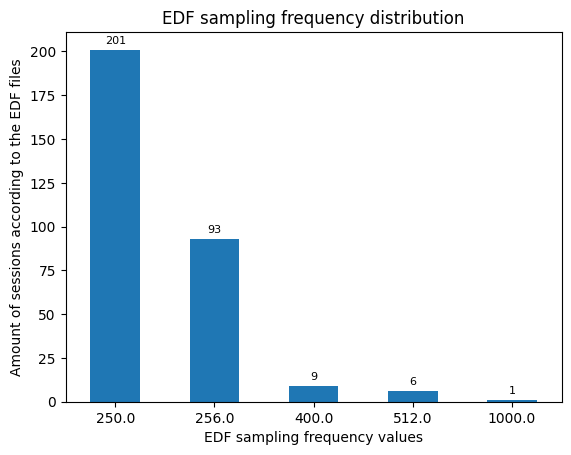


>> Distribution of the amount of channels


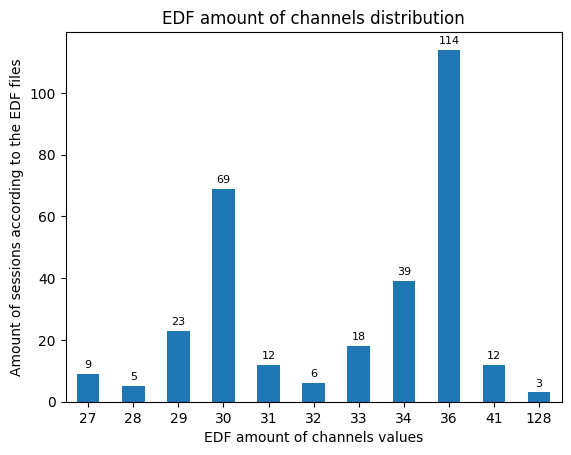


>> Channel matrix preview


Amount of channels,27,28,29,30,31,32,33,34,36,41,128,Total files,N variants present
Channels,,,,,,,,,,,,,
EEG C3-REF,9,5,23,69,12,6,17,39,114,0,3,297,10
EEG C4-REF,9,5,23,69,12,6,17,39,114,0,3,297,10
EEG CZ-REF,9,5,23,69,12,6,17,39,114,0,3,297,10
EEG F3-REF,9,5,23,69,12,6,17,39,114,0,3,297,10
EEG F4-REF,9,5,23,69,12,6,17,39,114,0,3,297,10


In [5]:
%matplotlib inline
## EDA Visualization
# General function to plot visualization for the given characteristic of the EDF Artifact corpus analysis
def plot_visualization(column_name, analyzed_parameter):
    """Plot visualization for the given dataframe column"""
    data = signal_sessions_corpus_df[column_name].value_counts().sort_index()
    axes = pd.DataFrame(data).reset_index().plot.bar(
        x=column_name,
        rot=0,
        title=f"EDF {analyzed_parameter} distribution",
        xlabel=f"EDF {analyzed_parameter} values",
        ylabel="Amount of sessions according to the EDF files",
        legend=False,
    )

    for container in axes.containers:
        axes.bar_label(container, label_type="edge", fontsize=8, padding=3)

    return axes

# Frecuency distribution of the sampling frequency
print("\n>> Distribution of the sampling frequency")
plot_visualization("Sampling frequency [Hz]", "sampling frequency")
plt.show()

# Channels distribution - examination of correct data channels
print("\n>> Distribution of the amount of channels")
plot_visualization("Amount of channels", "amount of channels")
plt.show()

# Examination of representative channels accordint to the amount found by the distribution
exploded = signal_sessions_corpus_df[["Amount of channels", "Channels"]].explode("Channels").sort_values(by="Amount of channels").reset_index(drop=True)
channel_matrix = pd.crosstab(exploded["Channels"], exploded["Amount of channels"])
channel_matrix["Total files"] = channel_matrix.drop(columns=[c for c in channel_matrix.columns if c == "Total files"], errors="ignore").sum(axis=1)
channel_matrix["N variants present"] = (channel_matrix.drop(columns="Total files") > 0).sum(axis=1)
channel_matrix = channel_matrix.sort_values(["N variants present", "Total files"], ascending=False)
print("\n>> Channel matrix preview")
display(channel_matrix.head(5))

#### Preview of EDF content


>> Sessions with 128 channels

>> Plotting a sample EDF file from the Artifact corpus with 128 channels
<Info | 8 non-empty values
 bads: []
 ch_names: EEG FP1-REF, EEG FP2-REF, EEG F3-REF, EEG F4-REF, EEG C3-REF, ...
 chs: 27 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2014-01-01 00:00:00 UTC
 nchan: 27
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: aaaaaels, sex: 2, last_name: aaaaaels>
>
Channels: ['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG T1-REF', 'EEG T2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF', 'EEG EKG1-REF', 'EEG A1-REF', 'EEG A2-REF', 'IBI', 'BURSTS', 'SUPPR']
Channel count: 27


C:\Users\ferch\AppData\Local\Temp\ipykernel_23628\2053615854.py:19: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot()


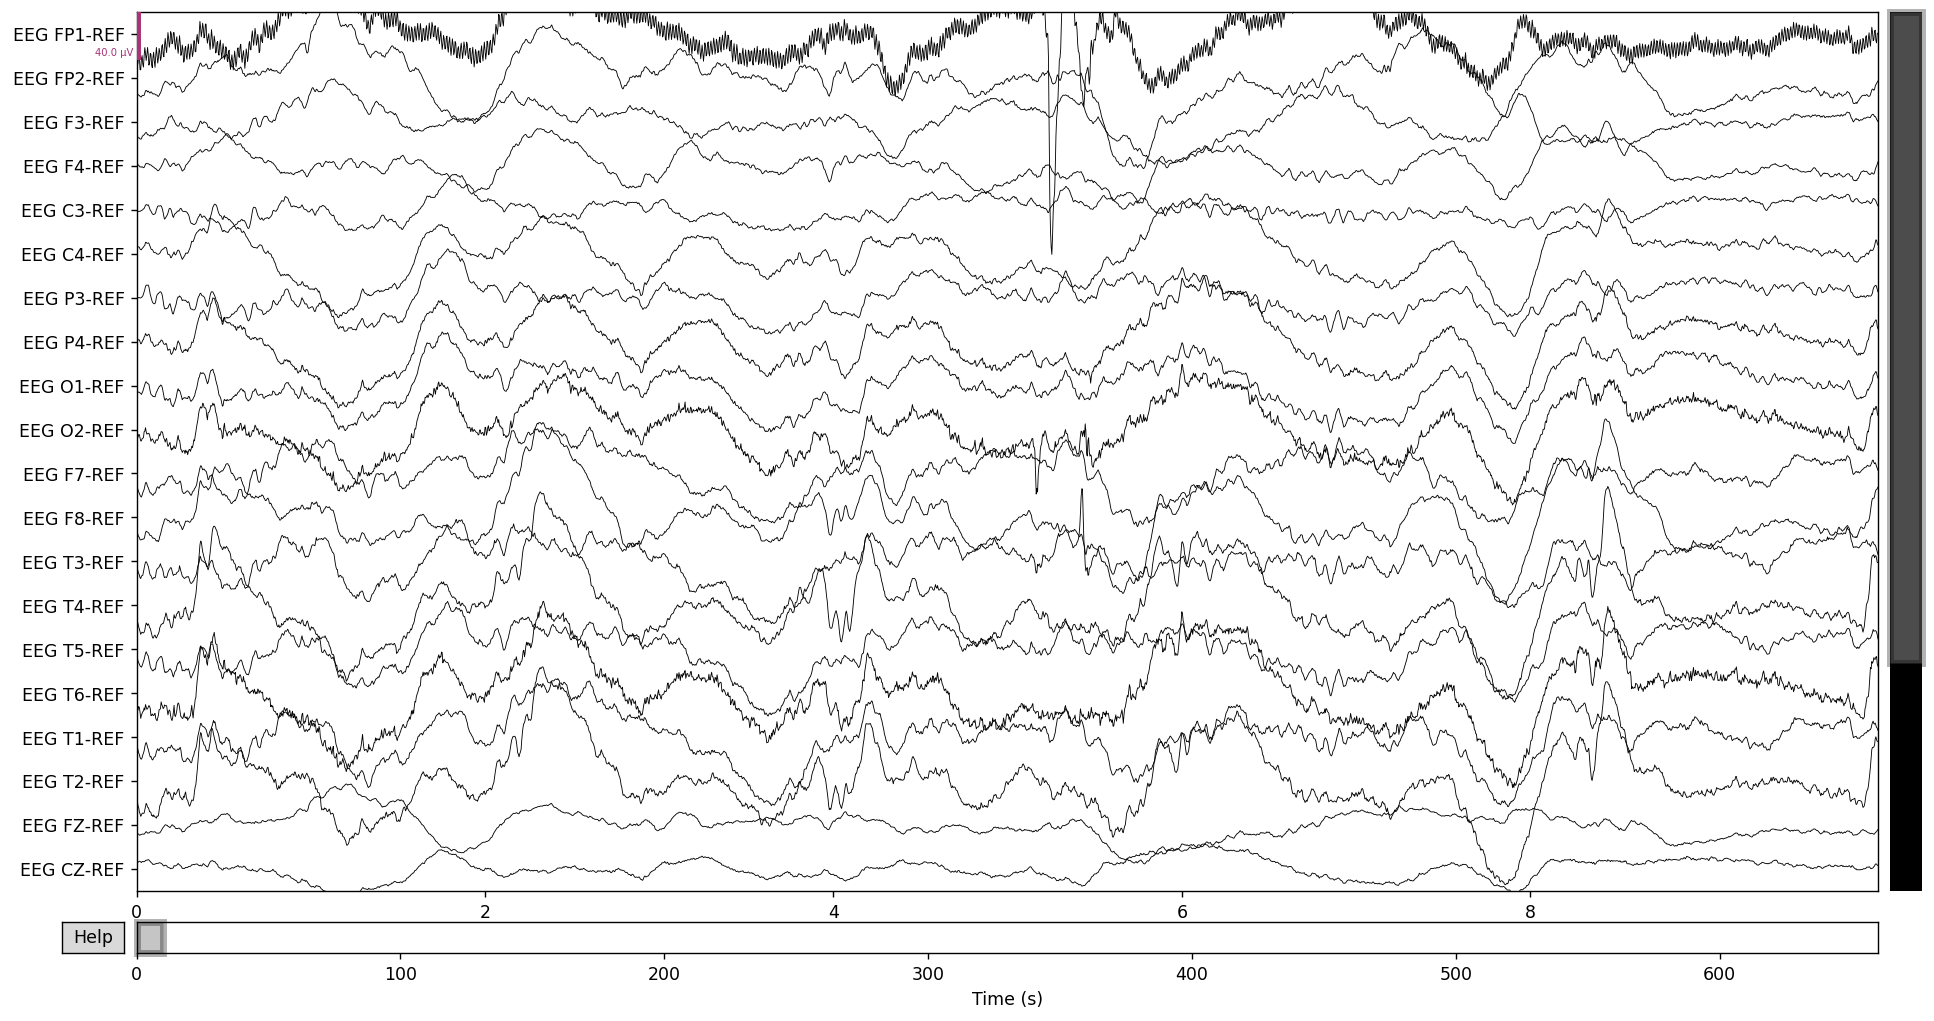

c:\Users\ferch\Documents\Various\EngineeringDesignAndInnovation\hybrid-ai-epilepsy-diagnosis\.venv\Lib\site-packages\matplotlib\cbook.py:361: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  func(*args, **kwargs)
c:\Users\ferch\Documents\Various\EngineeringDesignAndInnovation\hybrid-ai-epilepsy-diagnosis\.venv\Lib\site-packages\matplotlib\cbook.py:361: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  func(*args, **kwargs)
c:\Users\ferch\Documents\Various\EngineeringDesignAndInnovation\hybrid-ai-epilepsy-diagnosis\.venv\Lib\site-packages\matplotlib\cbook.py:361: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge a

In [20]:
%matplotlib qt

# Manual analysis of sessions with 128 channels to determine the most representative channels for the corpus
print("\n>> Sessions with 128 channels")
filtered_signals = signal_sessions_corpus_df.loc[signal_sessions_corpus_df["Amount of channels"] == 27]

print("\n>> Plotting a sample EDF file from the Artifact corpus with 128 channels")
raw = mne.io.read_raw_edf(
    filtered_signals["Path"].iloc[0],
    preload=False,
    verbose="WARNING",
)
print(raw.info)
print("Channels:", raw.ch_names)
print("Channel count:", len(raw.ch_names))

raw.plot()

#### Patients distribution and characteristics

In [10]:
# Sessions reported per patient
print("\n>> Sessions per patient")
sessions_per_patient = signal_sessions_corpus_df["Patient"].value_counts()
display(sessions_per_patient.describe())

# Amount of sessions per patient
print("\n>> Sessions per patient database (head)")
display(signal_sessions_corpus_df["Patient"].value_counts().head(30))


>> Sessions per patient


count    213.000000
mean       1.455399
std        1.183268
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       10.000000
Name: count, dtype: float64


>> Sessions per patient database (head)


Patient
aaaaanrc    10
aaaaajrj     7
aaaaamhb     7
aaaaapas     6
aaaaabbn     5
aaaaajns     5
aaaaabiw     4
aaaaacyf     4
aaaaadmi     4
aaaaajqo     4
aaaaajrf     4
aaaaamcr     4
aaaaamyc     4
aaaaappv     4
aaaaafcf     3
aaaaaimu     3
aaaaakbz     3
aaaaakeq     3
aaaaalzg     3
aaaaanhb     3
aaaaaogd     3
aaaaapks     3
aaaaagqb     3
aaaaabnn     3
aaaaaaju     2
aaaaagsc     2
aaaaahte     2
aaaaajah     2
aaaaajqu     2
aaaaalbt     2
Name: count, dtype: int64

### Annotations files

In [11]:
## Annotations
# Format analysis of the annotations
path = signal_sessions_corpus_df["Path"].iloc[0].with_suffix(".csv")

text = path.read_text(encoding="utf-8", errors="replace")
comments = [line for line in text.splitlines() if line.startswith("#")]
print(comments)

ann = pd.read_csv(
    path,
    sep=",", 
    comment="#"
)

display(ann.head(5))

['# version = csv_v1.0.0', '# bname = aaaaaaju_s005_t000', '# duration = 1442.0000 secs', '# montage_file = $TUAR/v3.0.0/DOCS/01_tcp_ar_montage.txt', '# annotation_label_file = $TUAR/v3.0.0/DOCS/nedc_ann_eeg_tools_map_v01.txt', '#']


,channel,start_time,stop_time,label,confidence
0,FP1-F7,22.9737,30.0688,eyem,1.0
1,FP1-F7,136.7987,140.1117,eyem,1.0
2,FP1-F7,145.0133,148.0498,eyem,1.0
3,F7-T3,22.9737,30.0688,eyem,1.0
4,F7-T3,136.7987,140.1117,eyem,1.0


In [12]:
# Corpus annotations data
def get_csv_data(base_path, corpus_name):
    """
    Returns all signal annotation marks of a specific corpus.
    """
    corpus_path = base_path / CORPUS_PATHS[corpus_name]
    montages = [
        "01_tcp_ar", "02_tcp_le", "03_tcp_ar_a", "04_tcp_le_a",
        "05_tcp_ar_b", "06_tcp_le_b", "07_tcp_ar_c", "08_tcp_le_c"
    ]

    registers = []

    for session in corpus_path.rglob("*.csv"):
        ann = pd.read_csv(session, sep=",", comment="#")

        text = session.read_text(encoding="utf-8", errors="replace")
        comments = [line for line in text.splitlines() if line.startswith("#")]

        montage = session.parent.name if session.parent.name in montages else None
        document_name = Path(session.name).stem
        session_id = next((part for part in document_name.split("_") if part.startswith("s") and part[1:].isdigit()), None)
        pacient = next((part for part in document_name.split("_") if len(part) == 8 and part.isalpha()), None)
        session_section = next((part for part in document_name.split("_") if part.startswith("t") and part[1:].isdigit()), None)

        ann = ann.assign(
            Montage=montage,
            Session=session_id,
            Patient=pacient,
            Section=session_section,
            WindowSize= lambda x: x["stop_time"] - x["start_time"],
        )

        registers.append(ann)

    return pd.concat(registers, ignore_index=True)

# CSVs Data extraction
data_sessions_artifact_df = get_csv_data(BASE_PATH, "artifact")
print("\n>> Sessions database preview")
display(data_sessions_artifact_df.head(5))



>> Sessions database preview


,channel,start_time,stop_time,label,confidence,Montage,Session,Patient,Section,WindowSize
0,FP1-F7,22.9737,30.0688,eyem,1.0,01_tcp_ar,s005,aaaaaaju,t000,7.0951
1,FP1-F7,136.7987,140.1117,eyem,1.0,01_tcp_ar,s005,aaaaaaju,t000,3.3130
2,FP1-F7,145.0133,148.0498,eyem,1.0,01_tcp_ar,s005,aaaaaaju,t000,3.0365
3,F7-T3,22.9737,30.0688,eyem,1.0,01_tcp_ar,s005,aaaaaaju,t000,7.0951
4,F7-T3,136.7987,140.1117,eyem,1.0,01_tcp_ar,s005,aaaaaaju,t000,3.3130


In [ ]:
# All registerd labels in the Artifact corpus
display(pd.DataFrame({"label": data_sessions_artifact_df["label"].unique()}))

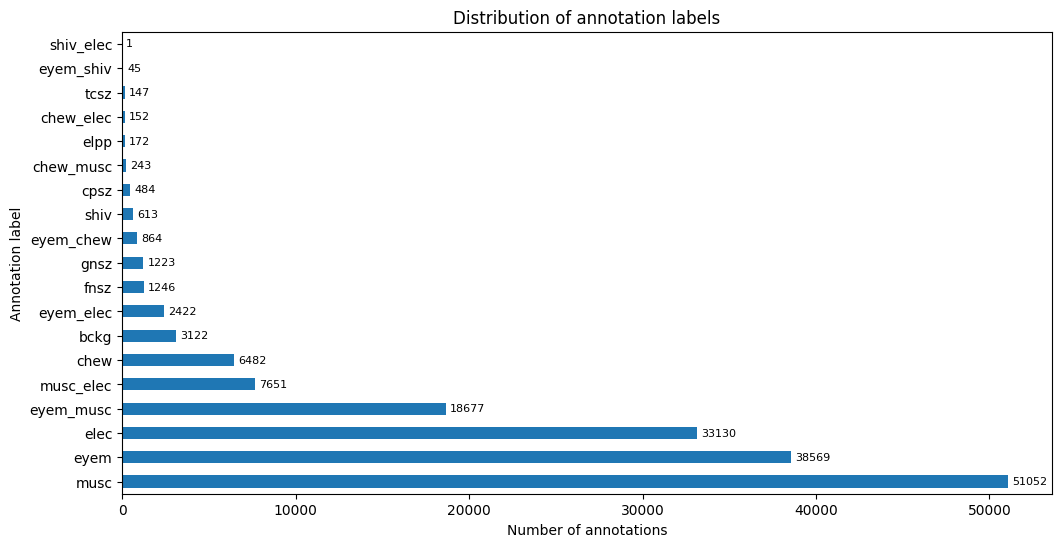

In [13]:
# Annotations distribution 
%matplotlib inline

data = data_sessions_artifact_df["label"].value_counts()
axes = pd.DataFrame(data).reset_index().plot.barh(
    x="label",
    rot=0,
    figsize=(12, 6),
    title=f"Distribution of annotation labels",
    xlabel=f"Number of annotations",
    ylabel="Annotation label",
    legend=False,
)

for container in axes.containers:
    axes.bar_label(container, label_type="edge", fontsize=8, padding=3)
plt.show()


Según la información de la tabla, el dataset está balanceado (desbalance clásico), favoreciendo el aprendizaje de los artefactos "musc", "eyem" y "elec" si no se analiza la información.

In [14]:
# Data correlation, annotations per session 
data_sessions_artifact_df["RecordID"] = (
    data_sessions_artifact_df["Patient"] + "_" +
    data_sessions_artifact_df["Session"] + "_" +
    data_sessions_artifact_df["Section"]
)
data_sessions_artifact_df["Tokens"] = (
    data_sessions_artifact_df["label"]
    .str.split("_")
)

data_sessions_artifact_df["NLabels"] = (
    data_sessions_artifact_df["Tokens"]
    .str.len()
)

print("\n>> Count of different labels by session")
print(data_sessions_artifact_df["NLabels"].value_counts())

SEIZURE_TOKENS = {"tcsz","cpsz","gnsz","fnsz"}

data_sessions_artifact_df["HasSeizure"] = (
    data_sessions_artifact_df["Tokens"]
    .apply(lambda x: any(label in SEIZURE_TOKENS for label in x))
)

ARTIFACT_TOKENS = {
    "eyem","musc","elec","elpp","chew","shiv"
}

data_sessions_artifact_df["HasArtifact"] = (
    data_sessions_artifact_df["Tokens"]
    .apply(lambda x: any(label in ARTIFACT_TOKENS for label in x))
)

record_summary = (
    data_sessions_artifact_df
    .groupby("RecordID")
    .agg({
        "HasArtifact":"max",
        "HasSeizure":"max"
    })
)

print("\n>> Count of records with artifacts and seizures by session")
print(record_summary.value_counts())


>> Count of different labels by session
NLabels
1    136240
2     30055
Name: count, dtype: int64

>> Count of records with artifacts and seizures by session
HasArtifact  HasSeizure
True         False         268
             True           42
Name: count, dtype: int64


Según los datos obtenidos se puede distribuir la información para tener suficientes datos para cada subclase según las características comunes, en el siguiente segmento se propone una distribución de las 19 clases disponibles teniendo en cuenta la cantidad de información de cada segmento.

#### Annotations categorization

In [ ]:
# Artifacts labels
ARTIFACT_KEYWORDS = {
    "eye": {"eyem"},
    "chew": {"chew"},
    "muscle": {"musc", "shiv"},
    "non_physiological": {"elec", "elpp"},
}

# Seizure exceptions due to recognition in the TUEV corpus
SEIZURE_TOKENS = {"tcsz", "cpsz", "gnsz", "fnsz"}

# Neutral label
BACKGROUND_LABEL = "bckg"

# Process to analyze data
def split_compound_label(label):
    return set(label.lower().split("_"))

#### Window generation

In [16]:
# Temporal (windowing) interaction by labels
def label_windows(annotations_df, window_size_sec):
    rows = []
    group_cols = ["Patient", "Session", "Section", "Montage"]

    for keys, session_group in annotations_df.groupby(group_cols):
        patient, session, section, montage = keys
        max_time = session_group["stop_time"].max()
        n_windows = int(max_time // window_size_sec)

        for w in range(n_windows):
            win_start = w * window_size_sec
            win_end = win_start + window_size_sec

            overlapping = session_group[
                (session_group["start_time"] < win_end) &
                (session_group["stop_time"] > win_start)
            ]

            raw_labels = list(overlapping["label"].unique())
            channels_involved = overlapping["channel"].nunique()

            all_tokens = set()
            for lbl in raw_labels:
                all_tokens |= split_compound_label(lbl)

            row = {
                "Patient": patient, "Session": session,
                "Section": section, "Montage": montage,
                "window_size": window_size_sec,
                "start": win_start, "end": win_end,
                "raw_labels": raw_labels,
                "n_channels_annotated": channels_involved,
            }

            for group_name, keywords in ARTIFACT_KEYWORDS.items():
                row[group_name] = int(bool(all_tokens & keywords))

            genuine_cooccurrence = False
            for lbl in raw_labels:
                tokens = split_compound_label(lbl)
                categories_hit = {g for g, kws in ARTIFACT_KEYWORDS.items() if tokens & kws}
                if len(categories_hit) > 1:
                    genuine_cooccurrence = True
                    break

            row["genuine_cooccurrence"] = int(genuine_cooccurrence)
            categories_present = sum(row[g] for g in ARTIFACT_KEYWORDS)
            row["weak_overlap"] = int(categories_present > 1 and not genuine_cooccurrence)

            row["has_seizure_activity"] = int(bool(all_tokens & SEIZURE_TOKENS))

            row["is_unreviewed"] = int(len(all_tokens) == 0)
            row["is_background"] = int(
                BACKGROUND_LABEL in all_tokens
                and not any(row[g] for g in ARTIFACT_KEYWORDS)
                and not row["has_seizure_activity"]
            )

            rows.append(row)

    return pd.DataFrame(rows)

t0 = time.time()
segments_df = label_windows(data_sessions_artifact_df, window_size_sec=1)
print(f"{time.time()-t0:.2f}s para {len(segments_df)} ventanas totales")

161.07s para 344482 ventanas totales


In [23]:
# Visualization
display(segments_df)

,Patient,Session,Section,Montage,window_size,start,end,raw_labels,n_channels_annotated,eye,chew,muscle,non_physiological,genuine_cooccurrence,weak_overlap,has_seizure_activity,is_unreviewed,is_background
0,aaaaaaju,s005,t000,01_tcp_ar,1,0,1,[],0,0,0,0,0,0,0,0,1,0
1,aaaaaaju,s005,t000,01_tcp_ar,1,1,2,[],0,0,0,0,0,0,0,0,1,0
2,aaaaaaju,s005,t000,01_tcp_ar,1,2,3,[],0,0,0,0,0,0,0,0,1,0
3,aaaaaaju,s005,t000,01_tcp_ar,1,3,4,[],0,0,0,0,0,0,0,0,1,0
4,aaaaaaju,s005,t000,01_tcp_ar,1,4,5,[],0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344477,aaaaatjz,s001,t000,03_tcp_ar_a,1,1893,1894,[bckg],22,0,0,0,0,0,0,0,0,1
344478,aaaaatjz,s001,t000,03_tcp_ar_a,1,1894,1895,[bckg],22,0,0,0,0,0,0,0,0,1
344479,aaaaatjz,s001,t000,03_tcp_ar_a,1,1895,1896,[bckg],22,0,0,0,0,0,0,0,0,1
344480,aaaaatjz,s001,t000,03_tcp_ar_a,1,1896,1897,[bckg],22,0,0,0,0,0,0,0,0,1


In [24]:
# Percentage of data that is unreviewed
print("\n>> Percentage of unreviewed data according to windowing analysis")
print(segments_df["is_unreviewed"].mean()*100, "%")  # si esto es ~1.0, algo está mal


>> Percentage of unreviewed data according to windowing analysis
48.71168885457005 %


In [25]:
## Results analysis  for windowing
print("\n>> Analysis of annotations according to windows of 1s to all corpus")
display(segments_df.head(30))

# Manual visualization
sample = data_sessions_artifact_df[
    (data_sessions_artifact_df["Patient"]=="aaaaaaju") &
    (data_sessions_artifact_df["Session"]=="s005")
]
print("\n>> Manual correlation to verify data")
print(sample[["channel","start_time","stop_time","label"]].head(5))


>> Analysis of annotations according to windows of 1s to all corpus


,Patient,Session,Section,Montage,window_size,start,end,raw_labels,n_channels_annotated,eye,chew,muscle,non_physiological,genuine_cooccurrence,weak_overlap,has_seizure_activity,is_unreviewed,is_background
0,aaaaaaju,s005,t000,01_tcp_ar,1,0,1,[],0,0,0,0,0,0,0,0,1,0
1,aaaaaaju,s005,t000,01_tcp_ar,1,1,2,[],0,0,0,0,0,0,0,0,1,0
2,aaaaaaju,s005,t000,01_tcp_ar,1,2,3,[],0,0,0,0,0,0,0,0,1,0
3,aaaaaaju,s005,t000,01_tcp_ar,1,3,4,[],0,0,0,0,0,0,0,0,1,0
4,aaaaaaju,s005,t000,01_tcp_ar,1,4,5,[],0,0,0,0,0,0,0,0,1,0
5,aaaaaaju,s005,t000,01_tcp_ar,1,5,6,[],0,0,0,0,0,0,0,0,1,0
6,aaaaaaju,s005,t000,01_tcp_ar,1,6,7,[],0,0,0,0,0,0,0,0,1,0
7,aaaaaaju,s005,t000,01_tcp_ar,1,7,8,[],0,0,0,0,0,0,0,0,1,0
8,aaaaaaju,s005,t000,01_tcp_ar,1,8,9,[],0,0,0,0,0,0,0,0,1,0
9,aaaaaaju,s005,t000,01_tcp_ar,1,9,10,[],0,0,0,0,0,0,0,0,1,0



>> Manual correlation to verify data
  channel  start_time  stop_time label
0  FP1-F7     22.9737    30.0688  eyem
1  FP1-F7    136.7987   140.1117  eyem
2  FP1-F7    145.0133   148.0498  eyem
3   F7-T3     22.9737    30.0688  eyem
4   F7-T3    136.7987   140.1117  eyem


In [26]:
data_sessions_artifact_df["label"]
data_sessions_artifact_df["label"].value_counts()
data_sessions_artifact_df.groupby("label")["WindowSize"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
bckg,3122.0,238.982662,349.265782,1.0000,25.76230,91.85680,376.74490,2352.0111
chew,6482.0,10.527261,21.001009,0.2945,1.81320,4.79180,11.12725,233.0350
chew_elec,152.0,128.375164,155.699448,1.9427,7.25250,27.36110,272.63190,434.2833
chew_musc,243.0,29.209626,24.916542,1.0986,9.97180,16.59290,48.25780,79.4469
cpsz,484.0,104.582705,52.769340,13.3657,63.63180,112.58865,137.67480,238.4000
elec,33130.0,6.518679,49.752302,0.0222,0.30830,0.91670,3.84120,1858.6248
elpp,172.0,1.188781,0.350740,0.9663,0.99580,1.00180,1.51150,1.9858
eyem,38569.0,5.276276,21.436560,0.1389,0.99910,1.83160,4.13880,1356.1207
eyem_chew,864.0,20.393904,91.740231,0.3828,0.97250,2.46070,5.90390,584.8844


,Windows,Percentage
eye,70791,32.79
chew,5699,2.64
muscle,86154,39.90
non_physiological,53274,24.67



>> Patients and label distribution


eye                  196
chew                  30
muscle               205
non_physiological    196
dtype: int64


>> Windows per patient distribution


count      213.000000
mean      1617.286385
std       1239.310067
min         11.000000
25%       1165.000000
50%       1238.000000
75%       1498.000000
max      10098.000000
dtype: float64

eye                  19.664167
chew                  1.583056
muscle               23.931667
non_physiological    14.798333
Name: Hours, dtype: float64

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
bckg,3122.0,238.982662,349.265782,1.0000,25.76230,91.85680,376.74490,2352.0111
chew,6482.0,10.527261,21.001009,0.2945,1.81320,4.79180,11.12725,233.0350
chew_elec,152.0,128.375164,155.699448,1.9427,7.25250,27.36110,272.63190,434.2833
chew_musc,243.0,29.209626,24.916542,1.0986,9.97180,16.59290,48.25780,79.4469
cpsz,484.0,104.582705,52.769340,13.3657,63.63180,112.58865,137.67480,238.4000
elec,33130.0,6.518679,49.752302,0.0222,0.30830,0.91670,3.84120,1858.6248
elpp,172.0,1.188781,0.350740,0.9663,0.99580,1.00180,1.51150,1.9858
eyem,38569.0,5.276276,21.436560,0.1389,0.99910,1.83160,4.13880,1356.1207
eyem_chew,864.0,20.393904,91.740231,0.3828,0.97250,2.46070,5.90390,584.8844


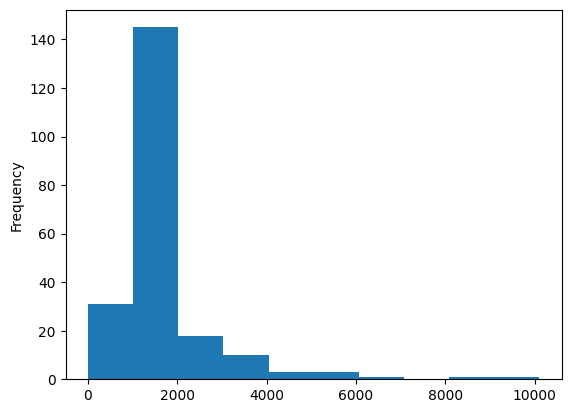

In [27]:
# Dataset balance by new labels (not 19)
artifact_counts = segments_df[list(ARTIFACT_KEYWORDS.keys())].sum()

artifact_percent = (
    artifact_counts / artifact_counts.sum() * 100
).round(2)

display(pd.DataFrame({
    "Windows": artifact_counts,
    "Percentage": artifact_percent
}))

# Patients per label
print("\n>> Patients and label distribution")
patients_per_class = {
    artifact:
        segments_df.loc[
            segments_df[artifact] == 1,
            "Patient"
        ].nunique()
    for artifact in ARTIFACT_KEYWORDS
}
display(pd.Series(patients_per_class))

# Windows per patient
print("\n>> Windows per patient distribution")
windows_per_patient = (
    segments_df.groupby("Patient").size()
)
display(windows_per_patient.describe())
windows_per_patient.plot.hist()

# Duration per label
duration = artifact_counts / 3600
display(duration.rename("Hours"))

# Original annotations duration
data_sessions_artifact_df.groupby("label")["WindowSize"].describe()